In [1]:
# =========================================================
# Day 5. 시계열 핵심 실습
# 파일: labeled_data.csv
# 목표: TimeStamp 기반 흐름 확인 + 간단 예측
# =========================================================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams["figure.figsize"] = (10, 4)

In [3]:
# ---------------------------------------------------------
# 1. 데이터 불러오기
# ---------------------------------------------------------
df = pd.read_csv("labeled_data.csv")

# 필요한 컬럼만 사용
df["TimeStamp"] = pd.to_datetime(df["TimeStamp"], errors="coerce")
df = df.dropna(subset=["TimeStamp"]).sort_values("TimeStamp").reset_index(drop=True)

# 불량 라벨 숫자로 변환 (Y=정상, N=불량 가정)
df["PassOrFail_binary"] = df["PassOrFail"].map({"Y": 0, "N": 1})

# 예측할 타깃
target_col = "Cycle_Time"

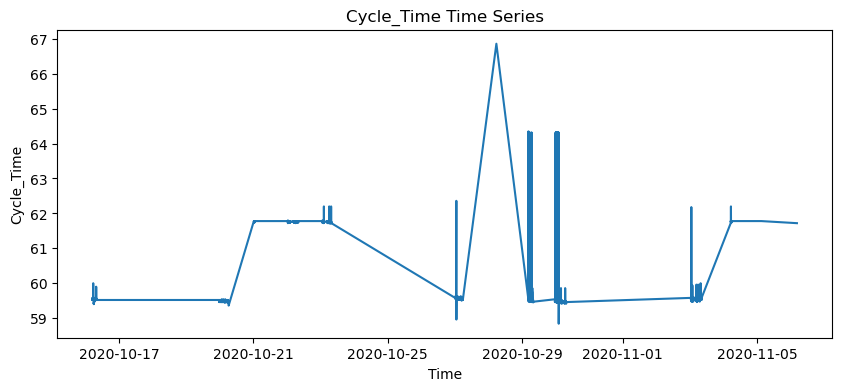

In [4]:
# ---------------------------------------------------------
# 2. 시계열 흐름 보기
# ---------------------------------------------------------
plt.plot(df["TimeStamp"], df[target_col])
plt.title("Cycle_Time Time Series")
plt.xlabel("Time")
plt.ylabel("Cycle_Time")
plt.show()

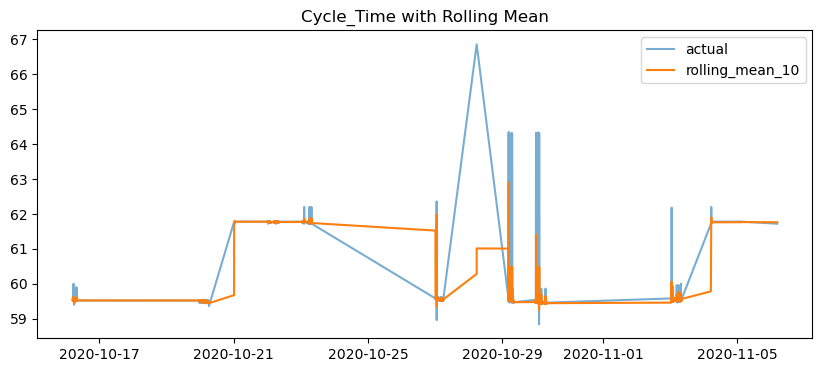

In [5]:
# ---------------------------------------------------------
# 3. rolling mean / rolling std
# ---------------------------------------------------------
df["rolling_mean_10"] = df[target_col].rolling(10).mean()
df["rolling_std_10"] = df[target_col].rolling(10).std()

plt.plot(df["TimeStamp"], df[target_col], label="actual", alpha=0.6)
plt.plot(df["TimeStamp"], df["rolling_mean_10"], label="rolling_mean_10")
plt.title("Cycle_Time with Rolling Mean")
plt.legend()
plt.show()

In [6]:
# ---------------------------------------------------------
# 4. lag / rolling feature 만들기
# ---------------------------------------------------------
df["lag_1"] = df[target_col].shift(1)
df["lag_3"] = df[target_col].shift(3)
df["lag_5"] = df[target_col].shift(5)

df["rolling_mean_3"] = df[target_col].shift(1).rolling(3).mean()
df["rolling_mean_5"] = df[target_col].shift(1).rolling(5).mean()

df["hour"] = df["TimeStamp"].dt.hour
df["dayofweek"] = df["TimeStamp"].dt.dayofweek

feature_cols = [
    "Injection_Time",
    "Filling_Time",
    "Max_Injection_Pressure",
    "lag_1",
    "lag_3",
    "lag_5",
    "rolling_mean_3",
    "rolling_mean_5",
    "hour",
    "dayofweek"
]

In [7]:
# ---------------------------------------------------------
# 5. 시간순 train / test split
# ---------------------------------------------------------
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

# 결측 보정
imputer = SimpleImputer(strategy="mean")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test = pd.DataFrame(imputer.transform(X_test), columns=feature_cols, index=X_test.index)

In [8]:
# ---------------------------------------------------------
# 6. Baseline 예측
# ---------------------------------------------------------
baseline_pred = test_df[target_col].shift(1)
baseline_pred.iloc[0] = train_df[target_col].iloc[-1]

In [9]:
# ---------------------------------------------------------
# 7. Linear Regression
# ---------------------------------------------------------
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

In [10]:
# ---------------------------------------------------------
# 8. Random Forest
# ---------------------------------------------------------
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [11]:
# ---------------------------------------------------------
# 9. 평가 함수
# ---------------------------------------------------------
def print_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)

    print(f"\n=== {name} ===")
    print("MAE :", round(mae, 4))
    print("RMSE:", round(rmse, 4))
    print("R²  :", round(r2, 4))

In [12]:
print_metrics(y_test, baseline_pred, "Baseline")
print_metrics(y_test, linear_pred, "Linear Regression")
print_metrics(y_test, rf_pred, "Random Forest")


=== Baseline ===
MAE : 0.0069
RMSE: 0.062
R²  : 0.983

=== Linear Regression ===
MAE : 0.0328
RMSE: 0.0496
R²  : 0.9891

=== Random Forest ===
MAE : 0.0102
RMSE: 0.0386
R²  : 0.9934


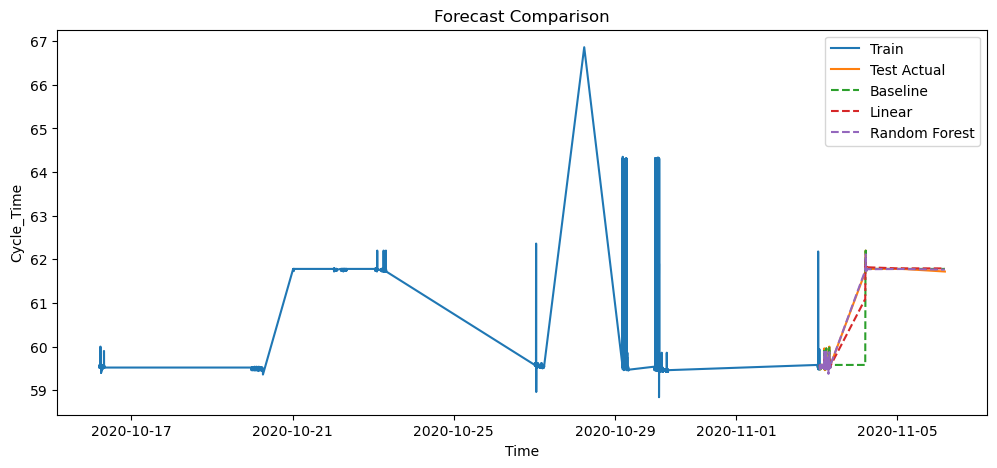

In [13]:
# ---------------------------------------------------------
# 10. 예측 결과 비교
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(train_df["TimeStamp"], train_df[target_col], label="Train")
plt.plot(test_df["TimeStamp"], y_test.values, label="Test Actual")
plt.plot(test_df["TimeStamp"], baseline_pred.values, label="Baseline", linestyle="--")
plt.plot(test_df["TimeStamp"], linear_pred, label="Linear", linestyle="--")
plt.plot(test_df["TimeStamp"], rf_pred, label="Random Forest", linestyle="--")
plt.title("Forecast Comparison")
plt.xlabel("Time")
plt.ylabel("Cycle_Time")
plt.legend()
plt.show()

In [14]:
# ---------------------------------------------------------
# 11. 중요 변수 확인
# ---------------------------------------------------------
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n=== 중요 변수 ===")
display(importance_df)


=== 중요 변수 ===


,feature,importance
1,Filling_Time,0.843415
2,Max_Injection_Pressure,0.107280
0,Injection_Time,0.044840
3,lag_1,0.002752
9,dayofweek,0.000498
7,rolling_mean_5,0.000477
5,lag_5,0.000285
4,lag_3,0.000187
6,rolling_mean_3,0.000136
8,hour,0.000130


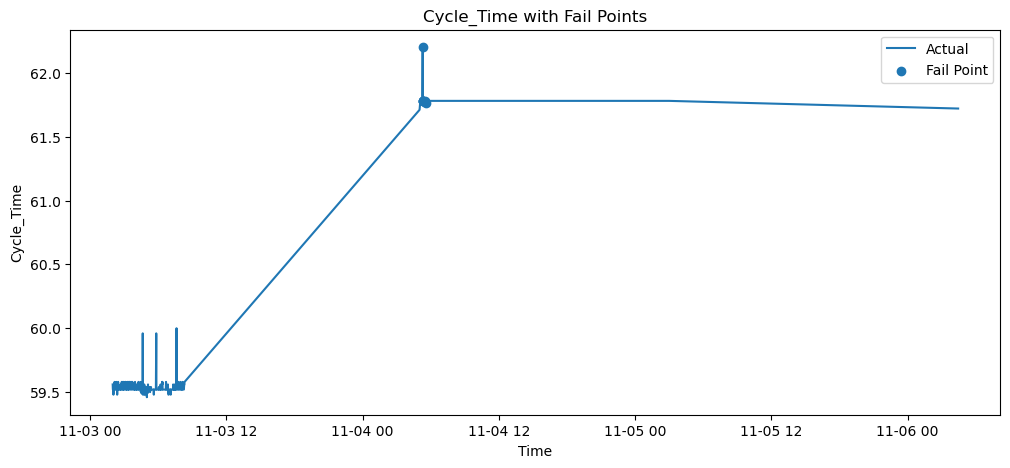

In [15]:
# ---------------------------------------------------------
# 12. 불량 발생 시점 같이 보기
# ---------------------------------------------------------
fail_df = test_df[test_df["PassOrFail_binary"] == 1]

plt.figure(figsize=(12, 5))
plt.plot(test_df["TimeStamp"], y_test.values, label="Actual")
plt.scatter(fail_df["TimeStamp"], fail_df[target_col], label="Fail Point")
plt.title("Cycle_Time with Fail Points")
plt.xlabel("Time")
plt.ylabel("Cycle_Time")
plt.legend()
plt.show()

In [16]:
# end